In [1]:
# imports
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
from skimage.feature import peak_local_max

In [39]:
# 0: channel 640, 1: channel 488, 2 Bright Field, 3: folder name
data = []

dir = os.getcwd()
dir_data = os.getcwd()[:dir.rfind('\\')] + "\\data"
for folder in os.listdir(dir_data):
    new_img = [None, None, None, folder]
    for file in os.listdir(os.path.join(dir_data, folder)):
        if str(file).endswith("colour0.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[0] = np.array(tempImg)
            new_img[0] = np.array([i[tempImg.shape[1]//2:tempImg.shape[1]] for i in tempImg])
        elif str(file).endswith("colour1.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[1] = np.array(tempImg)
            new_img[1] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
        elif str(file).endswith("colour2.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[2] = np.array(tempImg)
            new_img[2] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
    data.append(new_img)
data.sort(key = lambda x : int(x[3].split("_")[1]))

In [40]:
# image read function
def printImg(imgs, map=None):
    fig = plt.figure(figsize=(8,15))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(imgs[i], cmap=map)
        plt.axis('off')

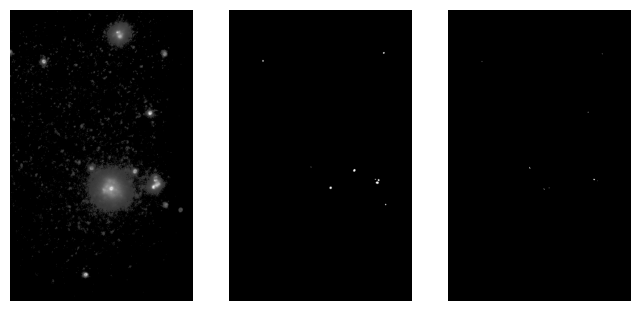

In [64]:
# boundary threshold
data_i = data[1][0:3].copy()
imgs_thresh = data_i.copy()
thresh_list = [90, 99.95, 99.99]
for i in range(len(imgsTest)):
    imgs_i = imgs_thresh[i].copy()
    qtl_i = np.percentile(imgs_i, thresh_list[i])
    threshold = qtl_i # 65535
    imgs_i[imgs_i < threshold] = 0
    # bound = cv2.inRange(imgsTest[i], int(np.amin(imgsTest[i]))-10, int(np.amax(imgsTest[i]))+10)
    imgs_thresh[i] =  imgs_i
printImg(imgs_thresh, "gray")

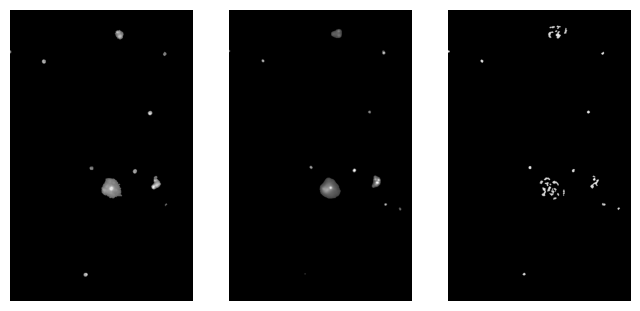

In [57]:
# Opening: erosion followed by dilation, removes small objects
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
# kernel = np.ones((3, 3), np.uint8)
imgs_opening = imgs_thresh.copy()

for i in range(len(imgs_opening)):
    imgs_i = imgs_opening[i].copy()
    opening = cv2.morphologyEx(imgs_opening[i], cv2.MORPH_OPEN, kernel)
    img_erosion = cv2.erode(imgs_i, kernel, iterations=1)
    img_dilation = cv2.dilate(img_erosion, kernel, iterations=1)
    imgs_opening[i] = opening
printImg(imgs_opening, "gray")

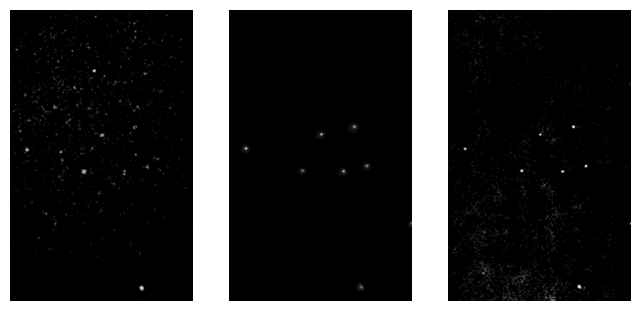

In [53]:
# test blur
imgsTest_blur = imgsTest.copy()
for i in range(len(imgsTest_blur)):
    blur = cv2.GaussianBlur(imgsTest_blur[i],(3,3), 4)
    imgsTest_blur[i] = blur
printImg(imgsTest_blur, "gray")

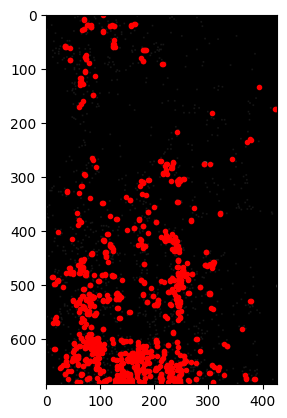

In [36]:
# img_peak = imgsTest_blur.copy()
# img_peak_blur = cv2.GaussianBlur(img_peak,(13,13), 4)
# ret1, img_otsu = cv2.threshold(img_peak, 0, 225, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# ret1, img_blur_otsu = cv2.threshold(img_peak, 0, 225, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# plt.imshow(img_peak)

# test peak
img_peak = imgsTest_blur.copy()
for i in range(len(img_peak)):
    peaks = peak_local_max(img_peak[i], threshold_abs=2000)
    plt.imshow(img_peak[i], cmap=plt.cm.gray)
    plt.plot(peaks[:, 1], peaks[:, 0], 'r.')
    plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

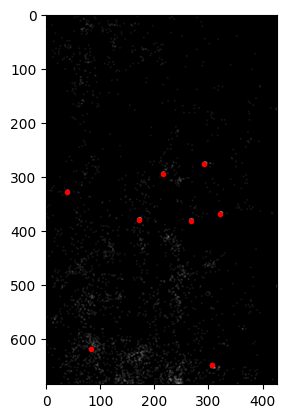

In [37]:
img_peak = imgsTest_blur[2].copy()
peaks = peak_local_max(img_peak, threshold_abs=np.percentile(img_peak, 99.95))
plt.imshow(img_peak, cmap=plt.cm.gray)
plt.plot(peaks[:, 1], peaks[:, 0], 'r.')
plt.show

In [38]:
data[90][3]

'pos_18'